# Steps

0. Preprocess + EDA + Feature Selection
1. Extract input and output cols
2. Scale the values
3. Train test split
4. Train the model
5. Evaluate the model/model selection
6. Deploy the model

In [11]:
import numpy as np
import pandas as pd
import seaborn as sns

In [4]:
df = pd.read_csv('DataSets/D13/placement.csv')

In [5]:
df.head()

,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  100 non-null    int64  
 1   cgpa        100 non-null    float64
 2   iq          100 non-null    float64
 3   placement   100 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 3.3 KB


In [7]:
df = df.iloc[:,1:]

In [8]:
df

,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
2,5.3,121.0,0
3,7.4,132.0,1
4,5.8,142.0,0
...,...,...,...
95,4.3,200.0,0
96,4.4,42.0,0
97,6.7,182.0,1
98,6.3,103.0,1


In [9]:
import matplotlib.pyplot as plt

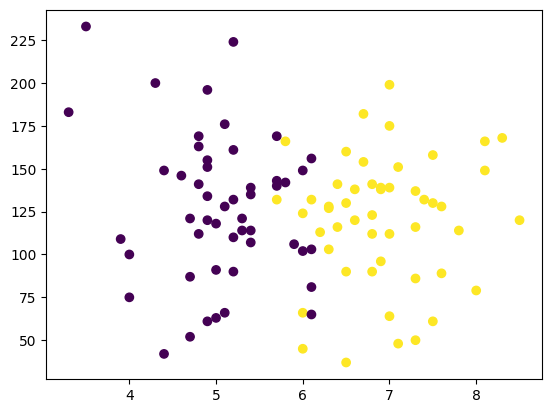

In [10]:
plt.scatter(df['cgpa'],df['iq'],c = df['placement'])
plt.show()

<Axes: xlabel='cgpa', ylabel='iq'>

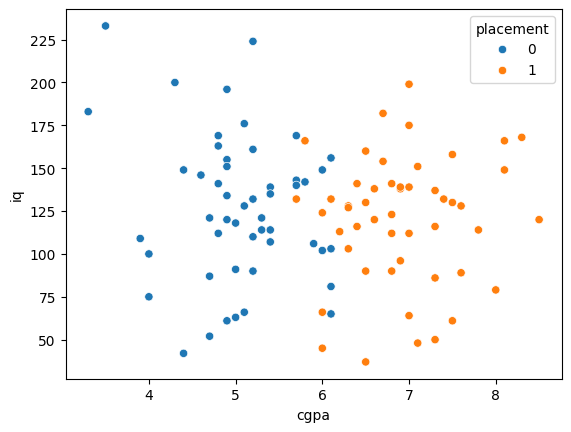

In [13]:
sns.scatterplot(x = df['cgpa'],y= df['iq'],hue=df['placement'])

In [14]:
X = df.iloc[:,0:2]
y = df.iloc[:,-1]

In [15]:
X.head()

,cgpa,iq
0,6.8,123.0
1,5.9,106.0
2,5.3,121.0
3,7.4,132.0
4,5.8,142.0


In [16]:
y.head()

0    1
1    0
2    0
3    1
4    0
Name: placement, dtype: int64

In [20]:
from sklearn.model_selection import train_test_split

In [33]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.1)

In [34]:
X_train

,cgpa,iq
84,5.7,169.0
2,5.3,121.0
9,5.1,66.0
48,6.6,138.0
99,6.2,113.0
...,...,...
57,6.5,130.0
37,8.1,149.0
91,7.5,158.0
92,5.2,110.0


In [35]:
from sklearn.preprocessing import StandardScaler

In [36]:
scaler = StandardScaler()

In [37]:
X_train = scaler.fit_transform(X_train)

In [38]:
X_test = scaler.transform(X_test)

In [39]:
X_test

array([[ 0.21753447, -0.50329727],
       [-1.01158408,  0.6726055 ],
       [-1.09937826,  1.11356904],
       [-1.80173172, -1.18924056],
       [-1.09937826, -0.2828155 ],
       [-0.04584807,  0.62360955],
       [-0.57261317,  0.3786298 ],
       [-1.18717245, -0.89526486],
       [-0.04584807,  0.01116019],
       [ 1.27106466,  0.15814803]])

In [40]:
from sklearn.linear_model import LogisticRegression

In [41]:
clf = LogisticRegression()

In [42]:
clf.fit(X_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [43]:
y_pred = clf.predict(X_test)

In [44]:
from sklearn.metrics import accuracy_score

In [45]:
accuracy_score(y_test,y_pred)

0.9

In [60]:
from mlxtend.plotting import plot_decision_regions

<Axes: >

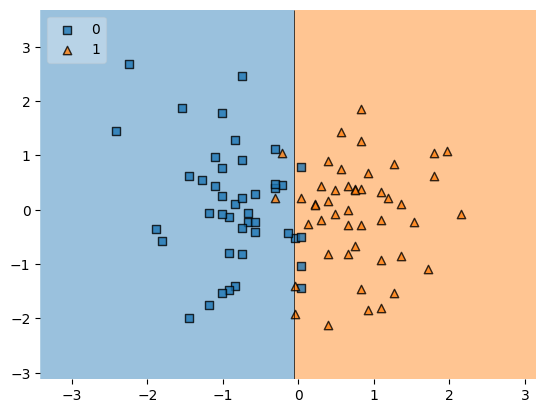

In [61]:
plot_decision_regions(X_train,y_train.values,clf = clf,legend = 2)

In [59]:
import pickle

In [60]:
pickle.dump(clf,open('model.pkl','wb'))